# **Work and Occupation Analysis:**

In [2]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings 
warnings.filterwarnings('ignore')

In [3]:
data= pd.read_csv('data.csv')

In [4]:
data.shape

(42468, 14)

In [5]:
data.columns

Index(['age', 'workclass', 'education', 'education-num', 'marital-status',
       'occupation', 'relationship', 'race', 'gender', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country', 'salary'],
      dtype='object')

In [6]:
data.head(3)

,age,workclass,education,education-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,salary
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K


### **1. Workclass Frequency:**

In [7]:
daa= data['workclass'].value_counts().reset_index(name= "Counts")
daa

,workclass,Counts
0,Private,28312
1,Self-emp-not-inc,3735
2,Local-gov,3011
3,Others,2411
4,State-gov,1927
5,Self-emp-inc,1644
6,Federal-gov,1397
7,Without-pay,21
8,Never-worked,10


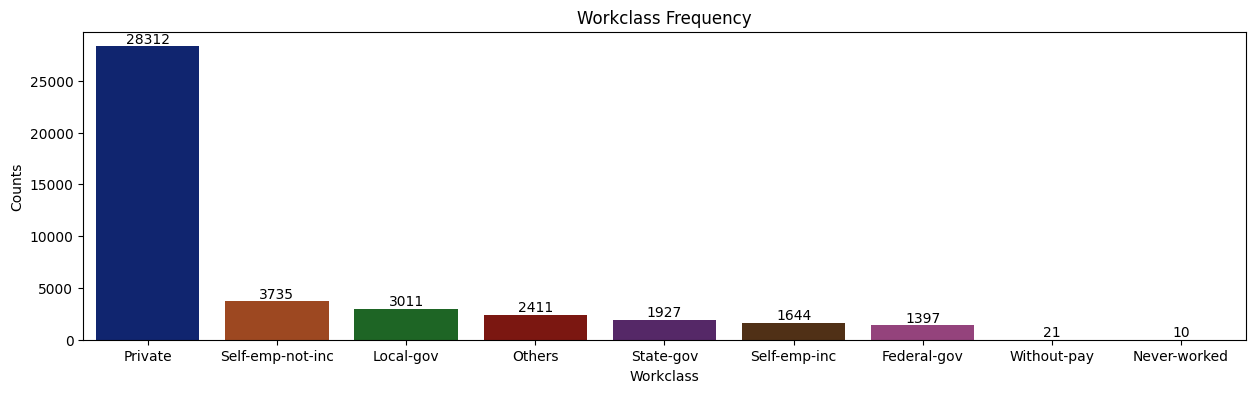

In [8]:
plt.figure(figsize=(15, 4))
sns.barplot(data= daa, x= 'workclass', y= 'Counts', palette= "dark", hue= "workclass")
# add annotations
for i, v in enumerate(daa['Counts']):
    plt.text(x= i, y= v, s= str(v), ha='center', va='bottom')
plt.title("Workclass Frequency")
plt.xlabel("Workclass")
plt.ylabel("Counts")
plt.show()

---
---
----

### **2. Average Salary by Workclass:**

In [9]:
data.columns

Index(['age', 'workclass', 'education', 'education-num', 'marital-status',
       'occupation', 'relationship', 'race', 'gender', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country', 'salary'],
      dtype='object')

In [10]:
data["workclass"].unique()

array(['Private', 'Local-gov', 'Others', 'Self-emp-not-inc',
       'Federal-gov', 'State-gov', 'Self-emp-inc', 'Without-pay',
       'Never-worked'], dtype=object)

In [11]:
data.head(3)

,age,workclass,education,education-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,salary
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K


In [12]:
data.groupby("workclass")["salary"].value_counts().reset_index(name= "Counts")

,workclass,salary,Counts
0,Federal-gov,<=50K,858
1,Federal-gov,>50K,539
2,Local-gov,<=50K,2126
3,Local-gov,>50K,885
4,Never-worked,<=50K,10
5,Others,<=50K,2150
6,Others,>50K,261
7,Private,<=50K,22022
8,Private,>50K,6290
9,Self-emp-inc,>50K,901


There, is workclass named `"Without-pay"`, ie. it belongs to a class where there no pay-check for the work. But here see, there are 21 instances of `without-pay` but they are actually salaried. This is probably because of data entry errors. Lets fix this:

In [13]:
data.loc[data["workclass"] == "Without-pay", "salary"] = "no_pay"

In [14]:
data["salary"].unique()

array(['<=50K', '>50K', 'no_pay'], dtype=object)

In [15]:
daa= data.groupby("workclass")["salary"].value_counts().reset_index(name= "Counts")
daa

,workclass,salary,Counts
0,Federal-gov,<=50K,858
1,Federal-gov,>50K,539
2,Local-gov,<=50K,2126
3,Local-gov,>50K,885
4,Never-worked,<=50K,10
5,Others,<=50K,2150
6,Others,>50K,261
7,Private,<=50K,22022
8,Private,>50K,6290
9,Self-emp-inc,>50K,901


AttributeError: module 'matplotlib.pyplot' has no attribute 'x'

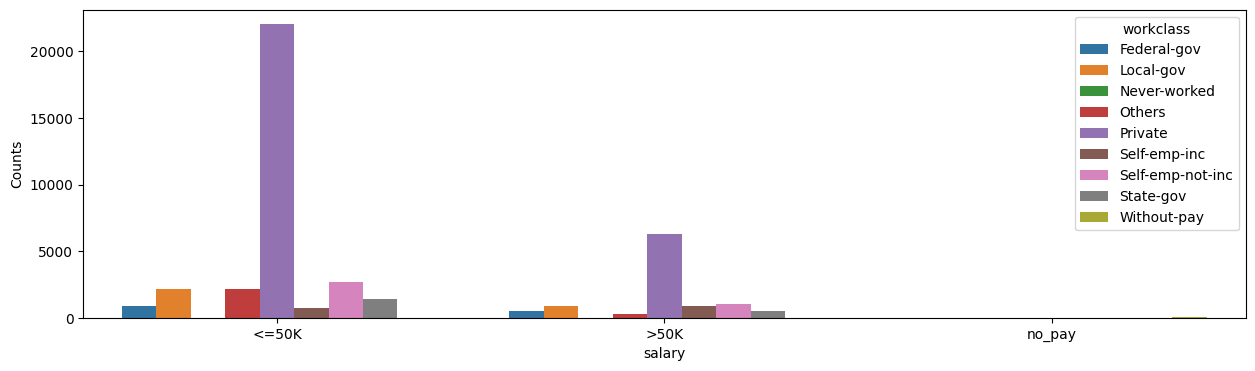

In [16]:
plt.figure(figsize=(15, 4))
sns.barplot(data= daa, x= "salary", y= "Counts", hue= "workclass")
plt.x

Majority of people have salary less then 50k and among them, Private jobclass accounts the most.For salary less then and greater than 50k private workclass accounts the most. 

----------------
-------
------
----
-----
------

### **3. Occupation Frequency:**

In [17]:
data.columns

Index(['age', 'workclass', 'education', 'education-num', 'marital-status',
       'occupation', 'relationship', 'race', 'gender', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country', 'salary'],
      dtype='object')

In [18]:
data["occupation"].unique()

array(['Machine-op-inspct', 'Farming-fishing', 'Protective-serv',
       'Others', 'Other-service', 'Prof-specialty', 'Craft-repair',
       'Adm-clerical', 'Exec-managerial', 'Tech-support', 'Sales',
       'Priv-house-serv', 'Transport-moving', 'Handlers-cleaners',
       'Armed-Forces'], dtype=object)

`Others` and `Other-service` are same things. Lets use `Others` for both of these cases:

In [19]:
data["occupation"]= data["occupation"].replace("Other-service", "Others")

In [20]:
data["occupation"].unique()

array(['Machine-op-inspct', 'Farming-fishing', 'Protective-serv',
       'Others', 'Prof-specialty', 'Craft-repair', 'Adm-clerical',
       'Exec-managerial', 'Tech-support', 'Sales', 'Priv-house-serv',
       'Transport-moving', 'Handlers-cleaners', 'Armed-Forces'],
      dtype=object)

In [23]:
oo= data.groupby(by= "occupation")["occupation"].value_counts().reset_index(name= "Counts").sort_values(by= "Counts", ascending= False)
oo

,occupation,Counts
7,Others,6787
9,Prof-specialty,5679
3,Exec-managerial,5412
0,Adm-clerical,4813
11,Sales,4766
2,Craft-repair,4726
6,Machine-op-inspct,2492
13,Transport-moving,2071
5,Handlers-cleaners,1738
4,Farming-fishing,1434


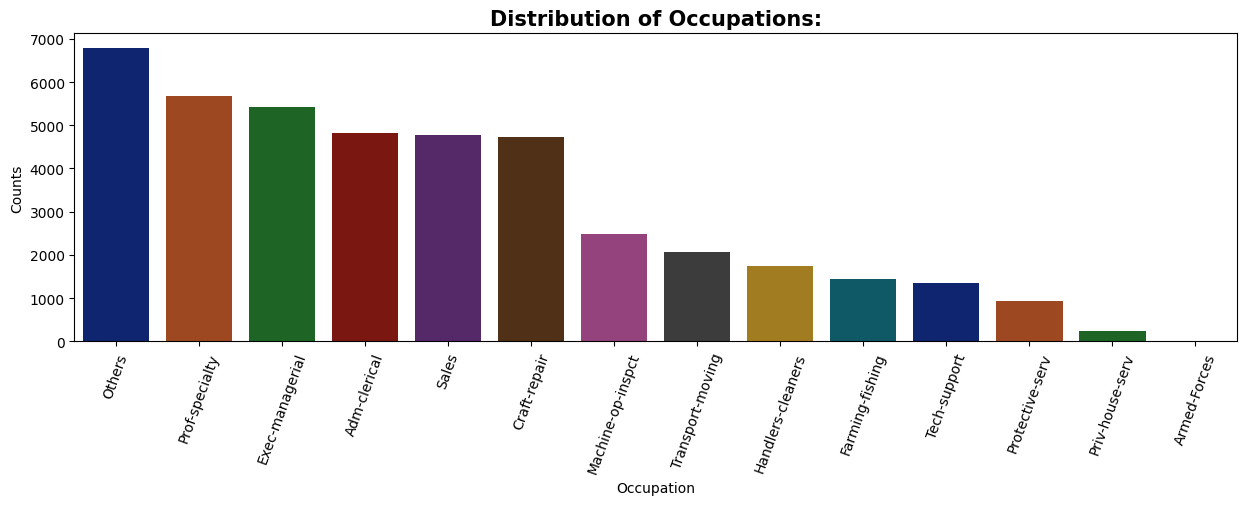

In [28]:
plt.figure(figsize=(15, 4))
sns.barplot(data= oo, x= "occupation", y= "Counts", palette= "dark", hue= "occupation")
plt.xticks(rotation= 70)
plt.title("Distribution of Occupations:", fontsize= 15, fontweight= "bold")
plt.xlabel("Occupation")
plt.ylabel("Counts")
plt.show()

---
----
----
----
----

### **4. Income Level by Occupation:**

In [29]:
data.columns

Index(['age', 'workclass', 'education', 'education-num', 'marital-status',
       'occupation', 'relationship', 'race', 'gender', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country', 'salary'],
      dtype='object')

In [30]:
data.head(3)

,age,workclass,education,education-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,salary
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K


In [32]:
occ= data.groupby(by= "occupation")["salary"].value_counts().reset_index(name= "No. of People") 
occ

,occupation,salary,No. of People
0,Adm-clerical,<=50K,4090
1,Adm-clerical,>50K,720
2,Adm-clerical,no_pay,3
3,Armed-Forces,<=50K,10
4,Armed-Forces,>50K,5
5,Craft-repair,<=50K,3621
6,Craft-repair,>50K,1104
7,Craft-repair,no_pay,1
8,Exec-managerial,<=50K,2882
9,Exec-managerial,>50K,2529


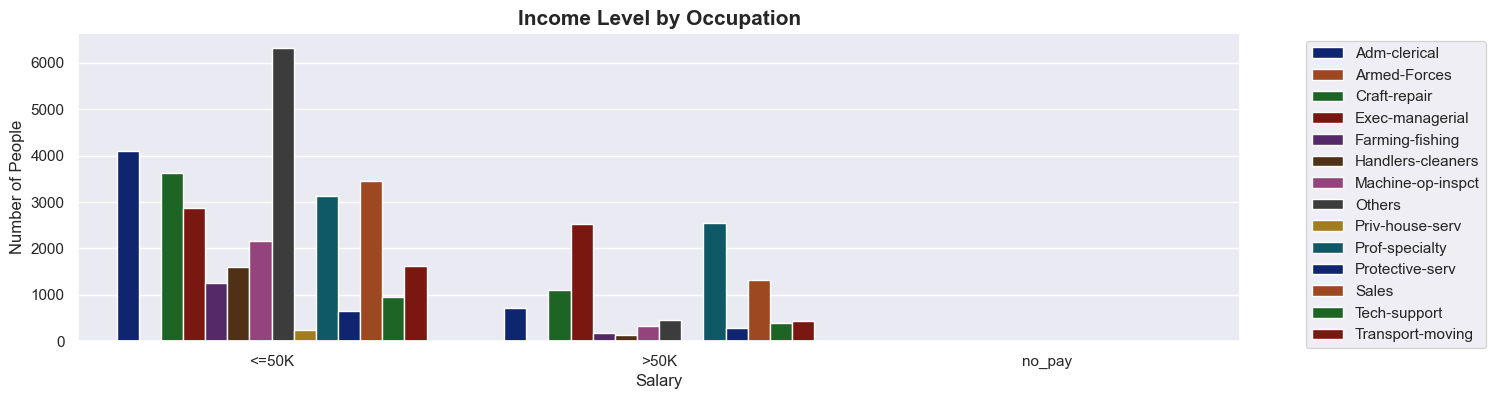

In [37]:
plt.figure(figsize=(15, 4))
sns.set_theme(style= "darkgrid")
sns.barplot(data= occ, hue= "occupation", y= "No. of People", x= "salary", palette= "dark")
plt.legend(bbox_to_anchor= (1.05, 1), loc= "upper left")
plt.title("Income Level by Occupation", fontsize= 15, fontweight= "bold")
plt.xlabel("Salary")
plt.ylabel("Number of People")
plt.show()

---
---
---


### **5. Hours Worked per Week by Occupation:**

* **Objective**: Find which occupations demand more time.
* **How**: Boxplot or bar chart of average `hours-per-week` grouped by `occupation`.
